Problem Statement Segment the Data —Scale the features, then apply K-Means (use the elbow method to pick k) and DBSCAN to the same data, and compare the groupings they produce. Use PCA to reduce the data to 2 dimensions and visualize the clusters from both algorithms on a scatter plot. https://www.kaggle.com/datasets/harrywang/wine-dataset-for-clustering

Import libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

Load the dataset

In [2]:
df = pd.read_csv("wine-clustering.csv")

df.head()

,Alcohol,Malic_Acid,Ash,Ash_Alcanity,Magnesium,Total_Phenols,Flavanoids,Nonflavanoid_Phenols,Proanthocyanins,Color_Intensity,Hue,OD280,Proline
0,14.23,1.71,2.43,15.6,127,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065
1,13.20,1.78,2.14,11.2,100,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050
2,13.16,2.36,2.67,18.6,101,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185
3,14.37,1.95,2.50,16.8,113,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480
4,13.24,2.59,2.87,21.0,118,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735


Check the dataset:

In [3]:
print(df.shape)
print(df.info())
print(df.isnull().sum())

(178, 13)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 178 entries, 0 to 177
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Alcohol               178 non-null    float64
 1   Malic_Acid            178 non-null    float64
 2   Ash                   178 non-null    float64
 3   Ash_Alcanity          178 non-null    float64
 4   Magnesium             178 non-null    int64  
 5   Total_Phenols         178 non-null    float64
 6   Flavanoids            178 non-null    float64
 7   Nonflavanoid_Phenols  178 non-null    float64
 8   Proanthocyanins       178 non-null    float64
 9   Color_Intensity       178 non-null    float64
 10  Hue                   178 non-null    float64
 11  OD280                 178 non-null    float64
 12  Proline               178 non-null    int64  
dtypes: float64(11), int64(2)
memory usage: 18.2 KB
None
Alcohol                 0
Malic_Acid              0
Ash        

Scale the features

In [4]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(df)

print(X_scaled.shape)

(178, 13)


Elbow method for K-Means

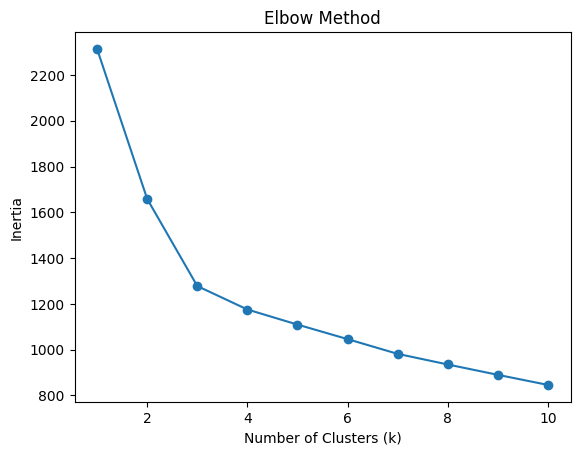

In [5]:
inertia = []

K = range(1, 11)

for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

plt.plot(K, inertia, marker='o')
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.show()

Apply K-Means

In [6]:
kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

kmeans_labels = kmeans.fit_predict(X_scaled)

df["KMeans_Cluster"] = kmeans_labels

df["KMeans_Cluster"].value_counts()

,count
KMeans_Cluster,
0,65
2,62
1,51


Apply DBSCAN

In [7]:
dbscan = DBSCAN(
    eps=2.5,
    min_samples=5
)

dbscan_labels = dbscan.fit_predict(X_scaled)

df["DBSCAN_Cluster"] = dbscan_labels

df["DBSCAN_Cluster"].value_counts()

,count
DBSCAN_Cluster,
0,154
-1,24


PCA — reduce to 2 dimensions

In [9]:
pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

pca_df = pd.DataFrame(
    X_pca,
    columns=["PC1", "PC2"]
)

pca_df.head()

,PC1,PC2
0,3.316751,1.443463
1,2.209465,-0.333393
2,2.516740,1.031151
3,3.757066,2.756372
4,1.008908,0.869831


Visualize K-Means clusters

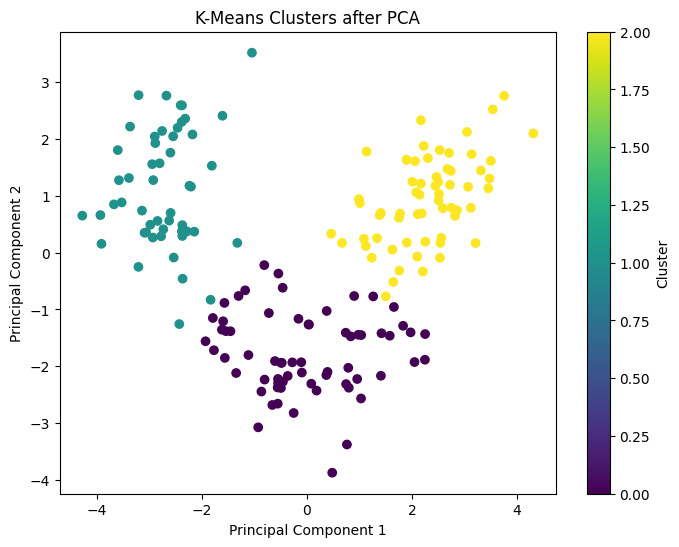

In [10]:
plt.figure(figsize=(8, 6))

plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=kmeans_labels,
    cmap="viridis"
)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("K-Means Clusters after PCA")
plt.colorbar(label="Cluster")
plt.show()

Visualize DBSCAN clusters

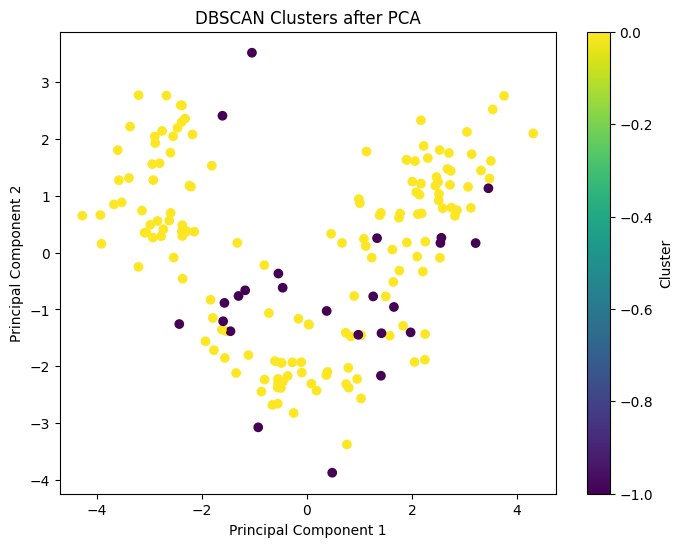

In [11]:
plt.figure(figsize=(8, 6))

plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=dbscan_labels,
    cmap="viridis"
)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("DBSCAN Clusters after PCA")
plt.colorbar(label="Cluster")
plt.show()

Compare K-Means and DBSCAN

In [12]:
print("K-Means clusters:")
print(pd.Series(kmeans_labels).value_counts())

print("\nDBSCAN clusters:")
print(pd.Series(dbscan_labels).value_counts())

K-Means clusters:
0    65
2    62
1    51
Name: count, dtype: int64

DBSCAN clusters:
 0    154
-1     24
Name: count, dtype: int64


K-Means divides every wine sample into one of k clusters. We selected k using the elbow method. It generally produces clear, compact groups but requires us to specify the number of clusters beforehand.

DBSCAN does not require us to specify the number of clusters. Instead, it groups points based on density and can identify unusual samples as noise (-1). Its results depend strongly on eps and min_samples.

PCA reduces the scaled features to two dimensions, allowing us to visually compare the clusters. If the K-Means PCA plot shows more clearly separated groups than DBSCAN, K-Means produced a cleaner grouping for the chosen parameters; if DBSCAN finds meaningful dense groups plus outliers, that highlights structure K-Means cannot represent.